In [1]:
# Setup

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

In [2]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics import CLUBS, Wind, find_velocity_for_distance

In [3]:
# Gerar grid de distâncias

results = []

club = CLUBS["1W"]
wind = Wind(speed=0, degree=0)

for target_distance in range(100, 301, 10):
    result = find_velocity_for_distance(
        target_distance=target_distance,
        club=club,
        wind=wind,
    )

    results.append(
        {
            "target_distance": result.target_distance,
            "velocity_z": result.velocity_z,
            "final_distance": result.final_distance,
            "error": result.error,
        }
    )

df_solver = pd.DataFrame(results)

df_solver

,target_distance,velocity_z,final_distance,error
0,100,50.000000,101.307128,1.307128
1,110,55.126953,109.926923,-0.073077
2,120,60.937500,120.442736,0.442736
3,130,66.406250,130.166138,0.166138
4,140,72.558594,139.791477,-0.208523
5,150,78.710938,150.261910,0.261910
6,160,84.521484,159.975887,-0.024113
7,170,91.699219,170.406663,0.406663
8,180,97.851562,180.239955,0.239955
9,190,105.029297,190.011634,0.011634


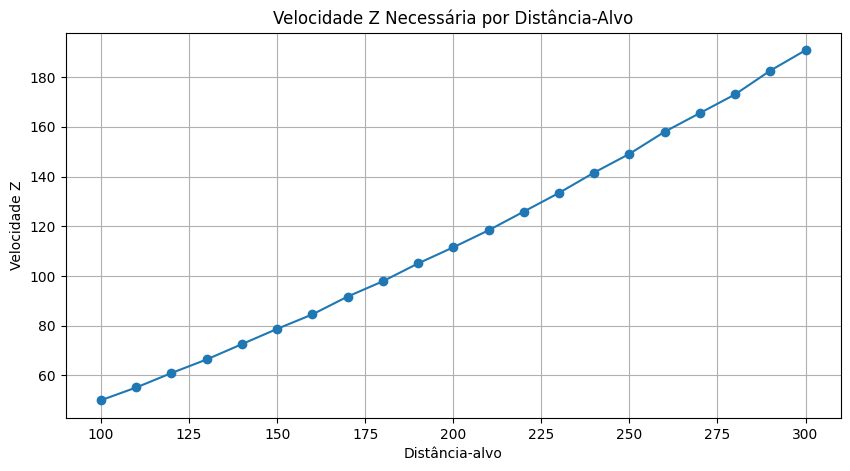

In [4]:
# Gráfico velocidade necessária

plt.figure(figsize=(10, 5))
plt.plot(df_solver["target_distance"], df_solver["velocity_z"], marker="o")
plt.title("Velocidade Z Necessária por Distância-Alvo")
plt.xlabel("Distância-alvo")
plt.ylabel("Velocidade Z")
plt.grid(True)
plt.show()

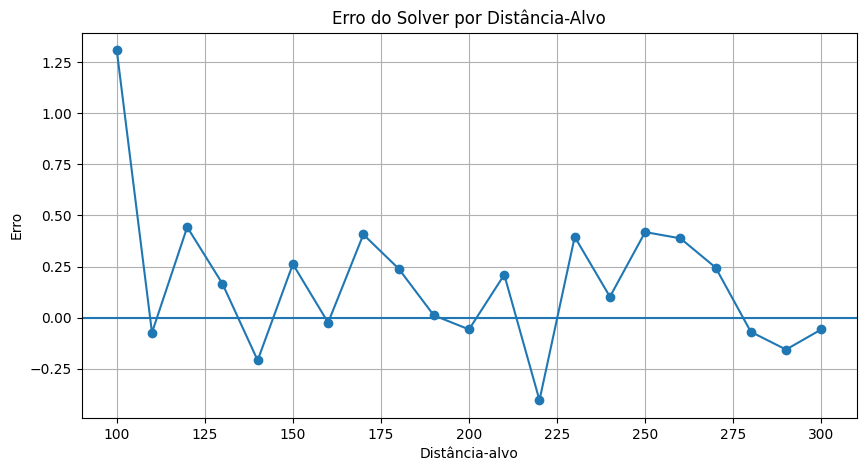

In [5]:
# Erro do Solver

plt.figure(figsize=(10, 5))
plt.plot(df_solver["target_distance"], df_solver["error"], marker="o")
plt.axhline(0)
plt.title("Erro do Solver por Distância-Alvo")
plt.xlabel("Distância-alvo")
plt.ylabel("Erro")
plt.grid(True)
plt.show()

In [6]:
# Comparação com vento

wind_scenarios = [
    ("Sem vento", Wind(speed=0, degree=0)),
    ("Vento a favor", Wind(speed=9, degree=0)),
    ("Vento contra", Wind(speed=9, degree=180)),
]

results = []

for label, wind in wind_scenarios:
    for target_distance in range(100, 301, 20):
        result = find_velocity_for_distance(
            target_distance=target_distance,
            club=club,
            wind=wind,
        )

        results.append(
            {
                "scenario": label,
                "target_distance": result.target_distance,
                "velocity_z": result.velocity_z,
                "final_distance": result.final_distance,
                "error": result.error,
            }
        )

df_wind = pd.DataFrame(results)

df_wind.head()

,scenario,target_distance,velocity_z,final_distance,error
0,Sem vento,100,50.000000,101.307128,1.307128
1,Sem vento,120,60.937500,120.442736,0.442736
2,Sem vento,140,72.558594,139.791477,-0.208523
3,Sem vento,160,84.521484,159.975887,-0.024113
4,Sem vento,180,97.851562,180.239955,0.239955


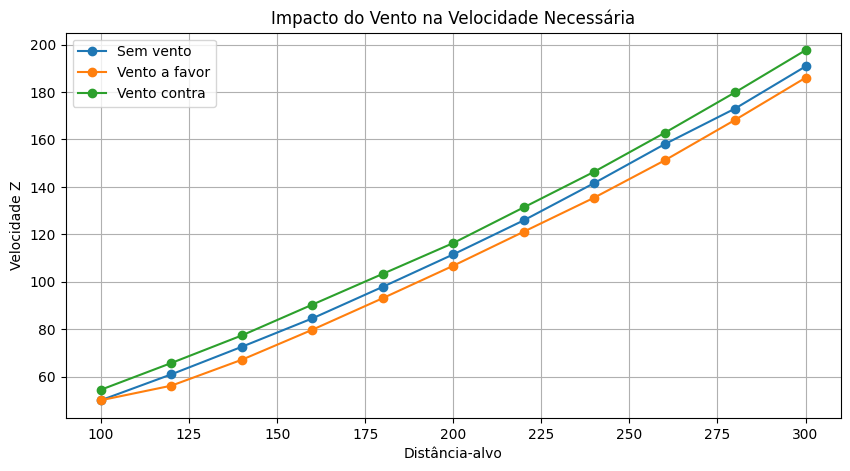

In [7]:
# Gráfico Vento

plt.figure(figsize=(10, 5))

for scenario in df_wind["scenario"].unique():
    sample = df_wind[df_wind["scenario"] == scenario]
    plt.plot(
        sample["target_distance"],
        sample["velocity_z"],
        marker="o",
        label=scenario,
    )

plt.title("Impacto do Vento na Velocidade Necessária")
plt.xlabel("Distância-alvo")
plt.ylabel("Velocidade Z")
plt.legend()
plt.grid(True)
plt.show()